In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [6]:
import sklearn
from sklearn.decomposition import PCA

In [7]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [8]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 2/16 photon absorption

In [9]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_env_ene(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_freq = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        f = dd['fogi_frequency']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_freq.append(f)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_freq[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_freq, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

In [26]:
header = "D:/K_sunada/result/CDY155/"
#time-reversed
data_0 = "/2024-02-18/2024-02-18T232403_5e086b3c-74_JPA_ab_waveform_qstate"
data_1 = "/2024-02-19/2024-02-19T113426_666405ba-74_JPA_ab_waveform_qstate"
data_2="/2024-02-18/2024-02-18T195430_1790310c-74_JPA_ab_waveform_qstate"
data_3="/2024-02-19/2024-02-19T103134_9e3926ab-74_JPA_ab_waveform_qstate"
data_4="/2024-02-19/2024-02-19T092045_b94cd442-74_JPA_ab_waveform_qstate"

<Figure size 800x600 with 0 Axes>

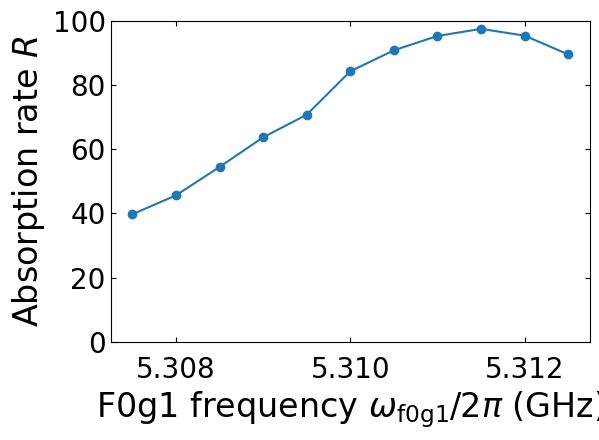

In [14]:
## absorption rate
ph_amp = 0
###############################################
data = data_0
num_of_ph_amp = 1
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 62.5e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
# ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('sq_abs_rate4.png', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

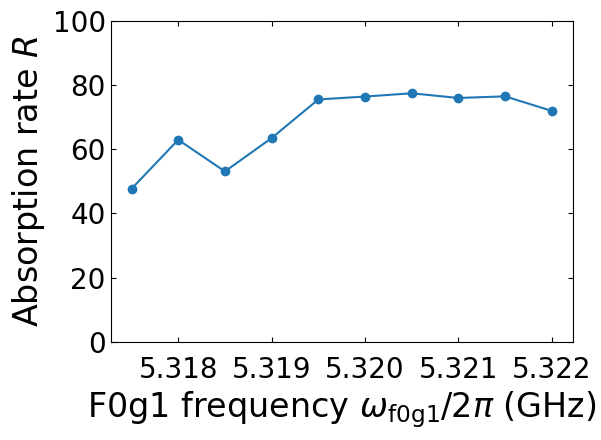

In [27]:
## absorption rate
ph_amp = 0
###############################################
data = data_1
num_of_ph_amp = 1
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 72.5e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
# ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('sq_abs_rate4.png', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

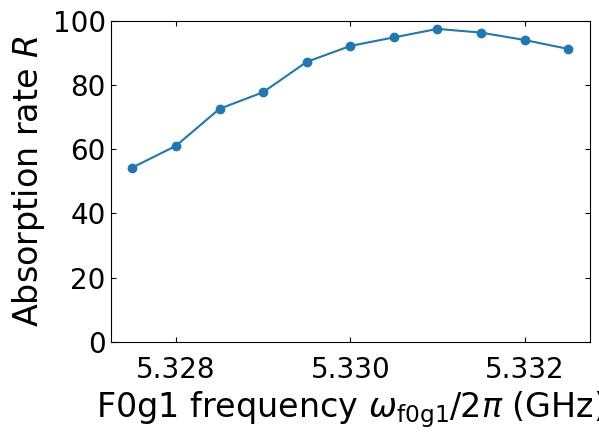

In [17]:
## absorption rate
ph_amp = 0
###############################################
data = data_2
num_of_ph_amp = 1
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 82.5e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
# ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('sq_abs_rate4.png', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

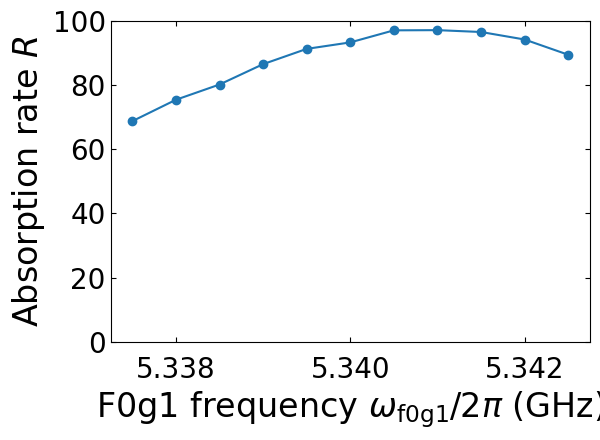

In [21]:
## absorption rate
ph_amp = 0
###############################################
data = data_3
num_of_ph_amp = 1
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 90e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
# ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('sq_abs_rate4.png', bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

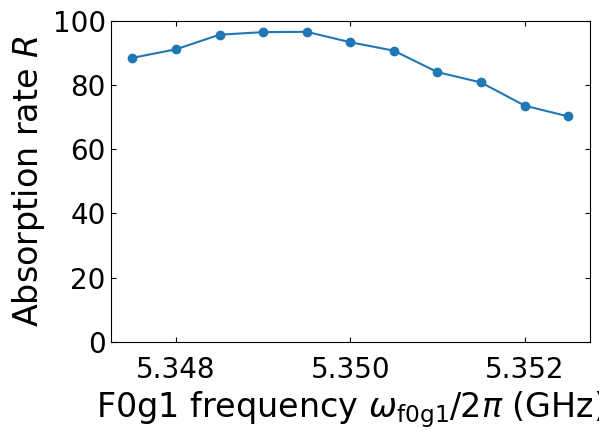

In [17]:
## absorption rate
ph_amp = 0
###############################################
data = data_4
num_of_ph_amp = 1
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 95e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
# ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('sq_abs_rate4.png', bbox_inches='tight')
plt.show()

In [9]:
sq_rate_half = [87.22, 89.11, 91.32, 91.32, 91.77]
sq_rate = [81.95, 85.03, 88.64, 89.26, 90.57]

<Figure size 1000x1000 with 0 Axes>

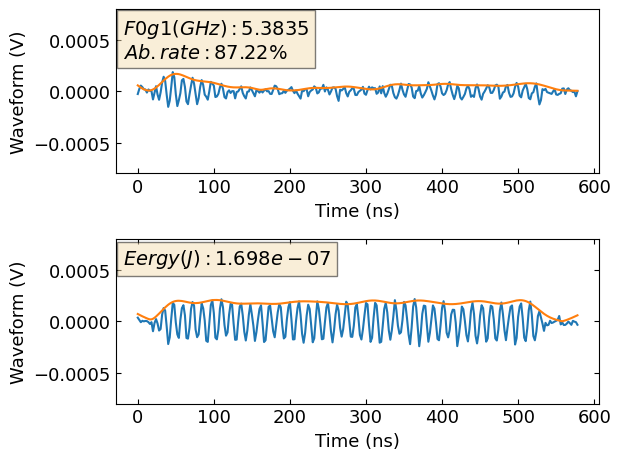

In [48]:
## env energy
ph_amp = 0
fogi_freq = 5
###############################################
data = data_square
num_of_ph_amp = 5
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

[37.52070921 45.58544219 59.03284413 77.59723504 92.33053095 98.77534629
 93.97475184 81.04637447 65.34493298 52.25779135 45.70717601]


<Figure size 800x600 with 0 Axes>

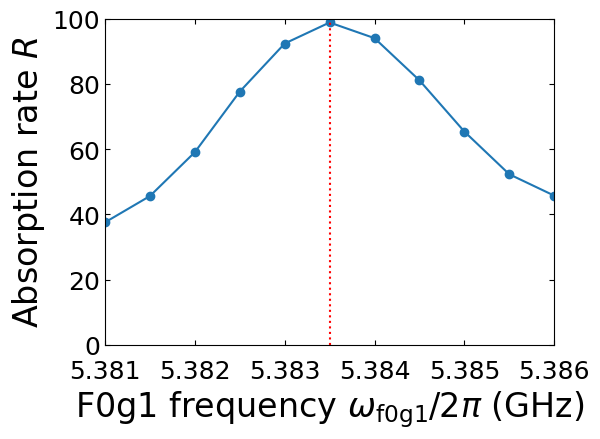

In [422]:
## absorption rate
ph_amp = 0
###############################################
data = data_tr
num_of_ph_amp = 8
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(5.381,5.386)
ax1.get_xaxis().set_tick_params(pad=10)
plt.vlines(5.3835, 0, 100, color='r', linestyles='dotted')
# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)
print(d[5][ph_amp])
plt.tight_layout()
# plt.savefig('tr_abs_rate0.png', bbox_inches='tight')
plt.show()

<Figure size 800x300 with 0 Axes>

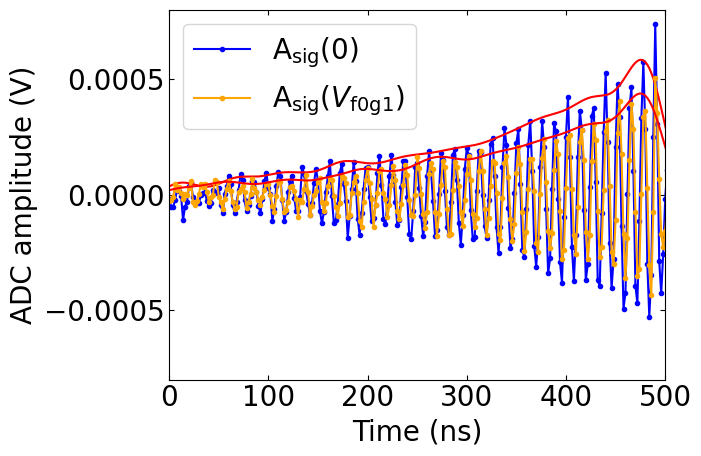

In [337]:
## absorption rate
ph_amp = 0
fogi_freq = 10
###############################################
data = data_tr
num_of_ph_amp = 8
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
ax0.set_xlim(0, 500)
plt.legend()
# plt.tight_layout()
# plt.savefig('tr_f0g1_10.png', bbox_inches='tight')
# plt.show()

<Figure size 800x600 with 0 Axes>

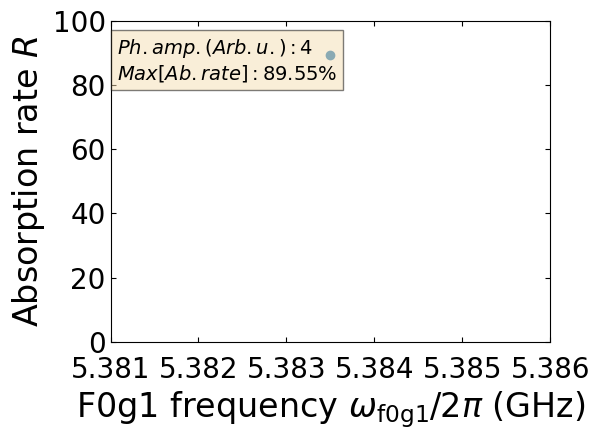

In [223]:
## absorption rate
ph_amp = 4
###############################################
data = data_tr1
num_of_ph_amp = 5
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(5.381,5.386)
ax1.get_xaxis().set_tick_params(pad=10)
# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, -10)

plt.tight_layout()
# plt.savefig('tr_abs_rate4.png', bbox_inches='tight')
plt.show()

In [12]:
tr_rate_half = [94.64, 89.2, 81.86, 77.57, 82.88]

In [13]:
tr_rate = [87.44, 87.28, 83.32, 81.69, 81.47]

<Figure size 800x1600 with 0 Axes>

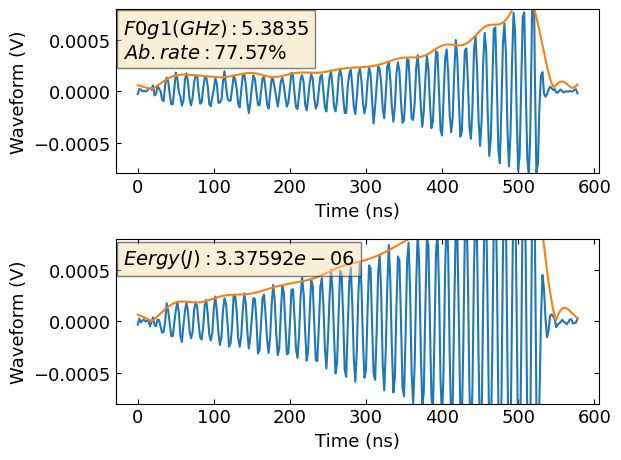

In [56]:
## env energy
ph_amp = 3
fogi_freq = 5
###############################################
data = data_tr
num_of_ph_amp = 5
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 79310344)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 16))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

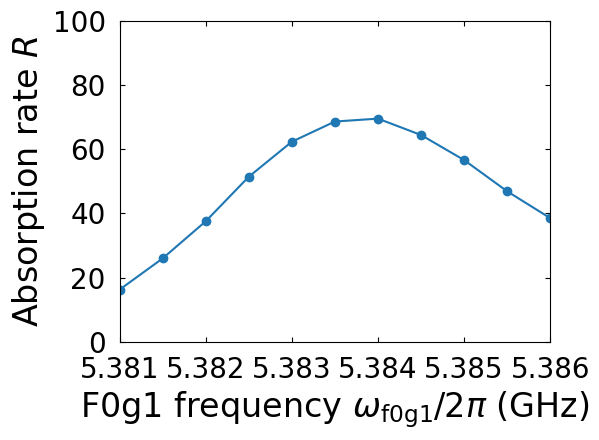

In [163]:
## absorption rate
ph_amp = 4
###############################################
data = data_utr
num_of_ph_amp = 5
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.tick_params(pad = 10,top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], 'o-')
ax1.set_xlabel('F0g1 frequency $\omega_{\mathrm{f0g1}}/2\pi$ (GHz)', size = "large")
ax1.set_ylabel('Absorption rate $R$', size = "large")
ax1.get_xaxis().set_tick_params(pad=10)
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(5.381,5.386)

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)

plt.tight_layout()
# plt.savefig('utr_abs_rate4.png', bbox_inches='tight')
plt.show()

In [16]:
utr_rate_half = [65.0, 65.89, 68.17, 68.97, 69.56]
utr_rate = [39.41, 41.44, 43.42, 44.45, 44.97]

<Figure size 1000x1000 with 0 Axes>

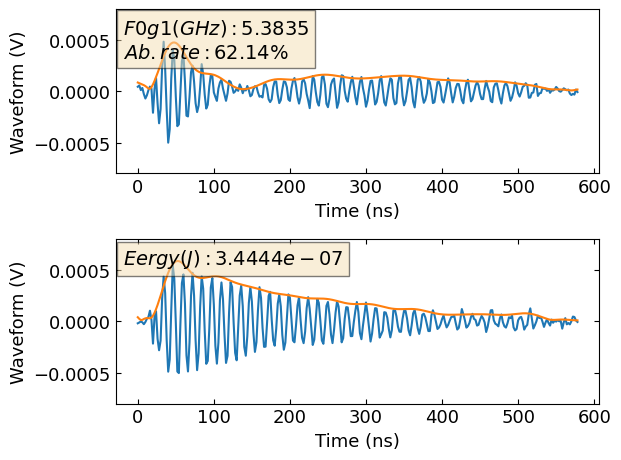

In [53]:
## waveform
ph_amp = 0
fogi_freq = 5
###############################################
data = data_utr
num_of_ph_amp = 5
num_of_fogi_freq = 11
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

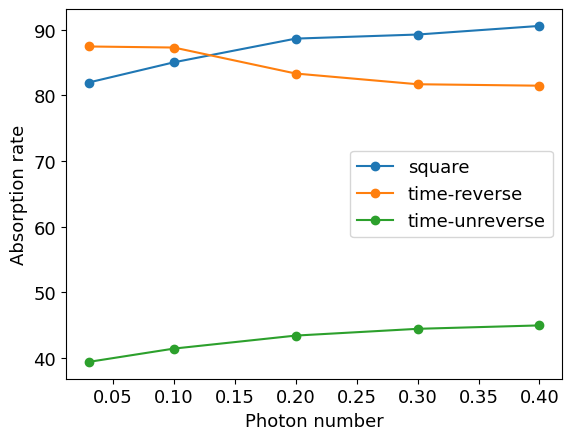

In [18]:
#nomal decay
ph_num = [0.03, 0.1, 0.2, 0.3, 0.4]
plt.xlabel("Photon number")
plt.ylabel("Absorption rate")
plt.plot(ph_num, sq_rate, 'o-', label = "square")
plt.plot(ph_num, tr_rate, 'o-',label = "time-reverse")
plt.plot(ph_num, utr_rate, 'o-',label = "time-unreverse")
plt.legend()

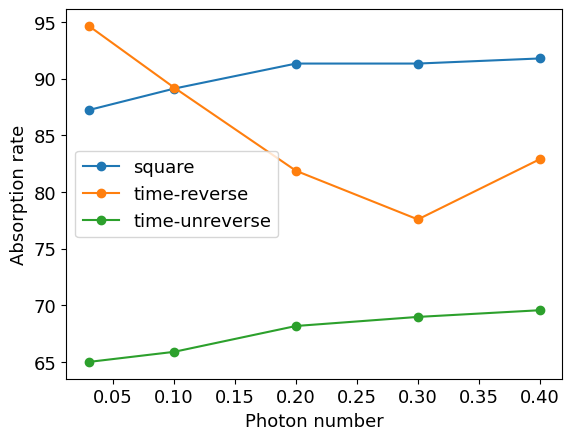

In [19]:
#nomal decay
ph_num = [0.03, 0.1, 0.2, 0.3, 0.4]
plt.xlabel("Photon number")
plt.ylabel("Absorption rate")
plt.plot(ph_num, sq_rate_half, 'o-', label = "square")
plt.plot(ph_num, tr_rate_half, 'o-',label = "time-reverse")
plt.plot(ph_num, utr_rate_half, 'o-',label = "time-unreverse")
plt.legend()

Fogi timing

In [18]:
fogi_timing = "/2024-02-18/2024-02-18T200429_7c7b71ef-75_JPA_ab_fogi_timing"
header = "D:/K_sunada/result/CDY155/"

In [19]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_timing(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    fogi_delay = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        d = dd['fogi_delay']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        fogi_delay.append(d)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(fogi_delay[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return fogi_delay, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

[70.50762018 74.12711287 78.65584683 80.83039813 81.04182269 85.53954686
 84.99084031 88.68982388 90.30775529 91.64369026 92.95540155 94.97806693
 96.02056144 96.92240973 96.44235703 97.83142723 98.13934763 97.58748852
 96.72302245 97.35301135 96.21721104 96.41690559 96.43016779 96.80959146
 96.93868148 96.59098652 96.29762941 96.7047785  97.38591753 96.78995527
 96.7063478  97.17778942 96.73688584 96.39053949 97.01554223 96.5971832
 97.45231864 97.35113445 96.68722168 97.7111799  97.67749387]
98.13934763207507 32.0


<Figure size 800x600 with 0 Axes>

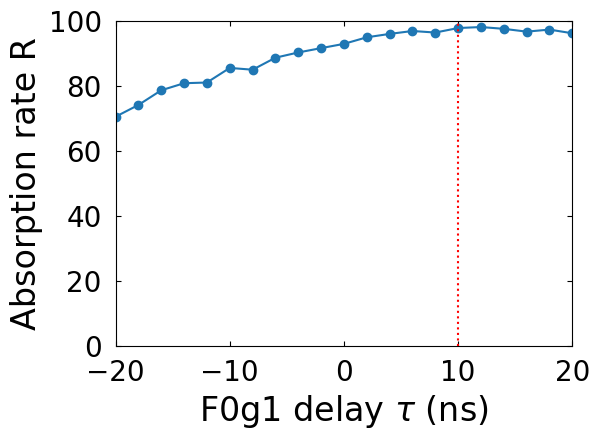

In [22]:
## absorption rate
ph_amp = 0
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_timing = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 82.5e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
# fig, (ax1, ax2) = plt.subplots(nrows=2)
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(pad=10, top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp]-20, d[5][ph_amp], "o-")
ax1.set_xlabel(r'F0g1 delay $\tau$ (ns)', size = "large")
ax1.set_ylabel('Absorption rate R', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(-20, 20)
plt.vlines(10, 0, 100, color='r', linestyles='dotted')

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print(d[5][ph_amp])
print(d[5][ph_amp][16], d[0][ph_amp][16])
plt.tight_layout()
# plt.savefig('fogi_delay_summary.png', bbox_inches='tight')
plt.show()

<Figure size 800x300 with 0 Axes>

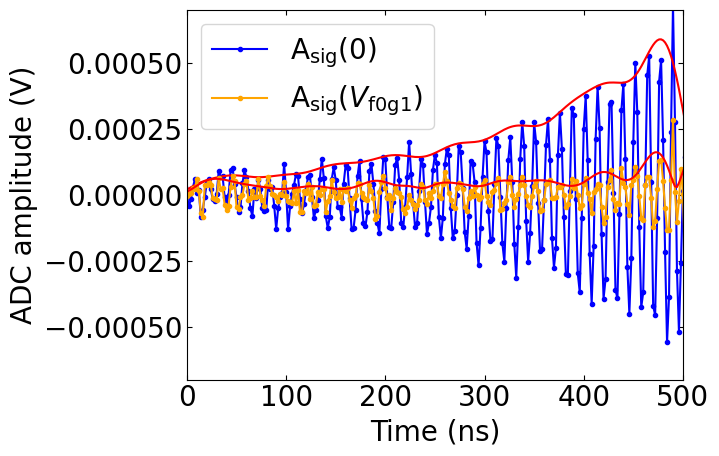

95.51


In [378]:
## waveform
ph_amp = 0
fogi_freq = 20
###############################################
data = fogi_timing
num_of_ph_amp = 1
num_of_fogi_freq = 41
###############################################
d = data_acquisition_timing(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0007, 0.0007)
ax0.set_xlim(0, 500)
plt.legend()
# plt.tight_layout()
# plt.savefig('fogi_delay_20.png', bbox_inches='tight')
plt.show()
# textstr0 = '\n'.join((r"$F0g1 timing (ns):{}$".format(np.round(freq, 4)-40),
#                       r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
# props0 = dict( facecolor='wheat', alpha=0.5)
# ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
#           fontsize=14,verticalalignment='top', bbox=props0)
print(np.round(ab_rate, 2))
plt.show()

ph duration


In [612]:
ph_du = "/2024-01-24/2024-01-24T160828_5f966154-77_JPA_ab_waveform_qstate_ph_length" #0.03
ph_du1 = "/2024-01-24/2024-01-24T151553_06f1cdfc-77_JPA_ab_waveform_qstate_ph_length" #0.1
ph_du2 = "/2024-01-24/2024-01-24T152532_6066ec35-77_JPA_ab_waveform_qstate_ph_length" #0.2
ph_du3 = "/2024-01-24/2024-01-24T185352_7ad2070b-77_JPA_ab_waveform_qstate_ph_length"
ph_du4 = "/2024-01-24/2024-01-24T143616_7e25aa49-77_JPA_ab_waveform_qstate_ph_length"#0.4
ph_du5 = "/2024-01-24/2024-01-24T184537_541f5c7b-77_JPA_ab_waveform_qstate_ph_length"
ph_du6 = "/2024-01-24/2024-01-24T190503_0b220d1a-77_JPA_ab_waveform_qstate_ph_length"
ph_du7 = "/2024-01-24/2024-01-24T144417_9d4d0b1e-77_JPA_ab_waveform_qstate_ph_length"#0.7
header = "D:/K_sunada/result/CDY154/"

In [505]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_ph_du(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    ph_du = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        l = dd['ph_length']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        ph_du.append(l)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(ph_du[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40-50*(7-n)):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return ph_du, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

[80.64835633 86.34869024 88.03438489 89.94340608 91.12710809 90.96928326
 91.42913288]


<Figure size 800x300 with 0 Axes>

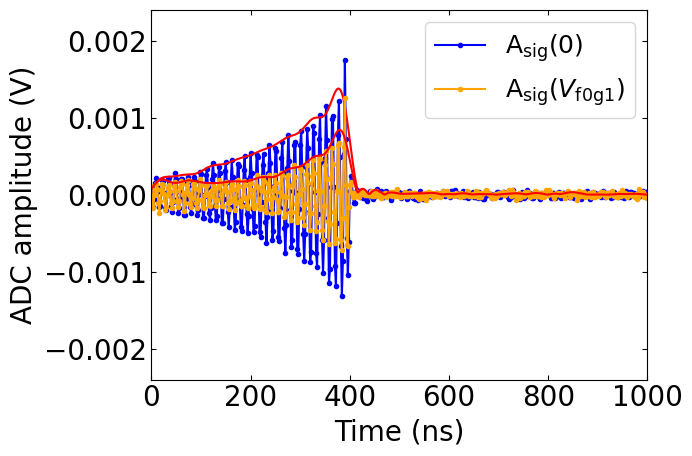

In [556]:
## absorption rate
ph_amp = 0
fogi_freq = 0
###############################################
data = ph_du7
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
freq = d[0][ph_amp]
energy = d[4][ph_amp]
ab_rate = d[5][ph_amp]
print(ab_rate)
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0024, 0.0024)
ax0.set_xlim(0, 1000)
plt.legend(loc = 'upper right', fontsize = 18)
# plt.tight_layout()
# plt.savefig('ph_du_tr400_4.png', bbox_inches='tight')
# plt.show()

[97.82318958 98.8619998  98.90010512 98.64598905 98.9455784  99.15105817
 98.61659585] [80.64835633 86.34869024 88.03438489 89.94340608 91.12710809 90.96928326
 91.42913288]


<Figure size 800x600 with 0 Axes>

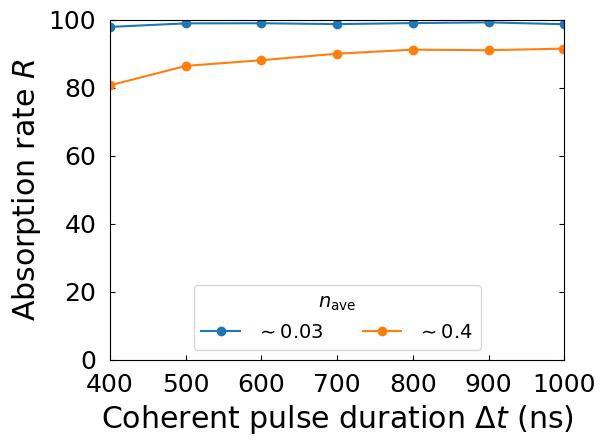

In [615]:
## absorption rate 0.03
ph_amp = 0
###############################################
data = ph_du
data1 = ph_du1
data2 = ph_du2
data3 = ph_du3
data4 = ph_du4
data5 = ph_du5
data6 = ph_du6
data7 = ph_du7

num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d1 = data_acquisition_ph_du(header, data1,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d2 = data_acquisition_ph_du(header, data2,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d3 = data_acquisition_ph_du(header, data3,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d4 = data_acquisition_ph_du(header, data4,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d5 = data_acquisition_ph_du(header, data5,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d6 = data_acquisition_ph_du(header, data6,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d7 = data_acquisition_ph_du(header, data7,num_of_ph_amp, num_of_fogi_timing, 78.89e6)

ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 18
plt.tick_params(pad=10, top='on',bottom='on`',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-", label=r"$\sim$0.03")
# ax1.plot(d1[0][ph_amp], d1[5][ph_amp], "o-", label=r"$\sim$0.1")
# ax1.plot(d2[0][ph_amp], d2[5][ph_amp], "o-", label=r"$\sim$0.2")
# ax1.plot(d3[0][ph_amp], d3[5][ph_amp], "o-", label="0.3")
# ax1.plot(d4[0][ph_amp], d4[5][ph_amp], "o-", label=r"$\sim$0.3")
# ax1.plot(d5[0][ph_amp], d5[5][ph_amp], "o-", label=r"$\sim$0.3")
# ax1.plot(d6[0][ph_amp], d6[5][ph_amp], "o-", label="0.6")
ax1.plot(d7[0][ph_amp], d7[5][ph_amp], "o-", label=r"$\sim$0.4")
ax1.set_xlabel(r'Coherent pulse duration $\Delta t$ (ns)', size = "large")
ax1.set_ylabel(r'Absorption rate $R$', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(400, 1000)
legend = plt.legend(title_fontsize=14, fontsize=14, loc='lower center', ncol=2)
legend.set_title("$n_\mathrm{ave}$")
# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp], d7[5][ph_amp])
plt.tight_layout()
# plt.savefig('Ph_duration_tr_defence.png', bbox_inches='tight')
plt.show()

In [508]:
tr_data = [[97.9125424114977,96.56429315477565,94.26269022315456,91.0080527659854,87.78336828940546,84.33400081729266,80.93269152277594,77.64306353638958], 
 [0.47231494,0.64571452,0.9583177,0.81862001,1.33066921,1.247527,1.27643877,1.24974972]]

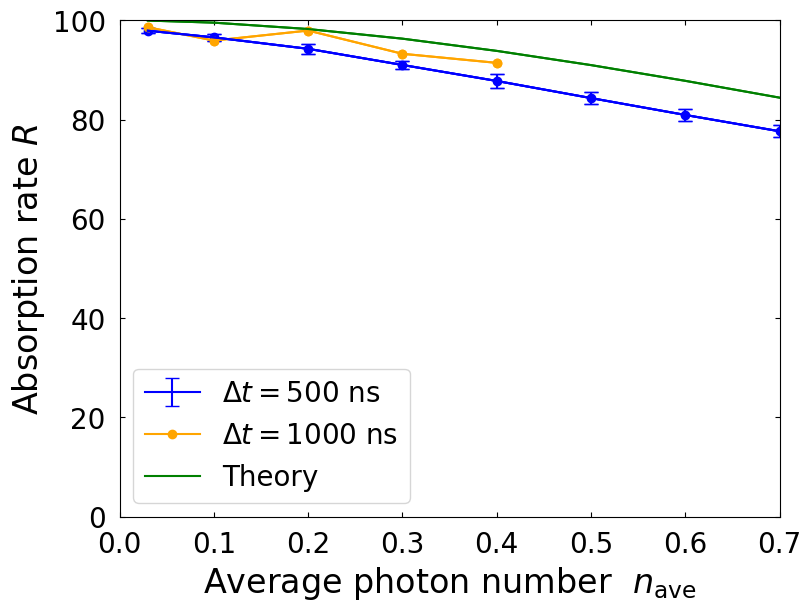

In [610]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(pad = 10,top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

x = np.array([0.03, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
rate_1000ns = [98.61, 95.92, 97.94, 93.26, 91.43]
rate_500ns = [97.9125424114977, 96.56429315477565, 94.26269022315456, 91.0080527659854,  87.78336828940546, 84.33400081729266, 80.93269152277594, 77.64306353638958]
F_tr = np.array([0.988, 0.978, 0.956, 0.927, 0.895])
ax.set_xlabel('Average photon number  $n_{\mathrm{ave}}$', size='large')
ax.set_ylabel('Absorption rate $R$', size='large')
# plt.plot(x, rate_500ns, 'o-',label="500ns")
plt.xlim(0.03, 0.7)
plt.ylim(0, 100)
ax.plot(x, rate_500ns, 'o-', color = "blue")
ax.errorbar(ph_num, tr_data[0], yerr=tr_data[1],  capsize=5, label=r"$\Delta t =$500 ns", color = "blue")
ax.plot([0.03, 0.1, 0.2, 0.3, 0.4], rate_1000ns, 'o-',label=r"$\Delta t =$1000 ns", color = "orange")
ax.plot(x, np.exp(-x)*(1+x)*100, label="Theory", color = "green")
p1 = ax.errorbar(ph_num, tr_data[0], yerr=tr_data[1],  capsize=5, label=r"$\Delta t =$500 ns", color = "blue")
p2 = ax.plot([0.03, 0.1, 0.2, 0.3, 0.4], rate_1000ns, 'o-',label=r"$\Delta t =$1000 ns", color = "orange")
p3 = ax.plot(x, np.exp(-x)*(1+x)*100, label="Theory", color = "green")
handles = [p1, p2[0], p3[0]]
labels = [p1.get_label(), p2[0].get_label(),p3[0].get_label()]
ax.legend(handles=handles, labels=labels)
ax.set_xlim(0, 0.7)
# plt.plot(np.array([0.03, 0.1, 0.2, 0.3, 0.4]), F_tr*100, label="fidelity")
# plt.savefig('abs_rate_final.png', bbox_inches='tight')


In [557]:
ph_du = "/2024-01-25/2024-01-25T093925_30798777-77_JPA_ab_waveform_qstate_ph_length"
ph_du1 = "/2024-01-27/2024-01-27T121831_bf91b8a4-77_JPA_ab_waveform_qstate_ph_length"
ph_du2 = "/2024-01-25/2024-01-25T095315_1fa451f3-77_JPA_ab_waveform_qstate_ph_length"
ph_du4 = "/2024-01-25/2024-01-25T100602_e8d60f0f-77_JPA_ab_waveform_qstate_ph_length"
ph_du5 = "/2024-01-27/2024-01-27T122705_f1b2d941-77_JPA_ab_waveform_qstate_ph_length"
ph_du7 ="/2024-01-25/2024-01-25T102049_f9158caf-77_JPA_ab_waveform_qstate_ph_length"

[63.17020181 52.8476217  55.48527721 51.44310755 49.48639492 50.75083359
 47.84289691]


<Figure size 800x600 with 0 Axes>

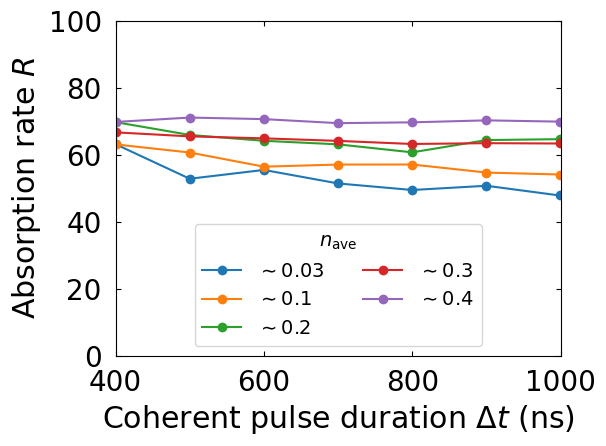

In [558]:
## absorption rate 0.7
ph_amp = 0
###############################################
data = ph_du
data1 = ph_du1
data2 = ph_du2
data5 = ph_du5
data7 = ph_du7
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d1 = data_acquisition_ph_du(header, data1,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d2 = data_acquisition_ph_du(header, data2,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d5 = data_acquisition_ph_du(header, data5,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
d7 = data_acquisition_ph_du(header, data7,num_of_ph_amp, num_of_fogi_timing, 78.89e6)

ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(8, 6))
fig, (ax1) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 18
plt.tick_params(pad=10, top='on',bottom='on`',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
# ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-", label="0.03")
# ax1.plot(d2[0][ph_amp], d2[5][ph_amp], "o-", label="0.2")
# ax1.plot(d4[0][ph_amp], d4[5][ph_amp], "o-", label="0.4")
# ax1.plot(d7[0][ph_amp], d7[5][ph_amp], "o-", label="0.7")

ax1.plot(d[0][ph_amp], d[5][ph_amp], "o-", label=r"$\sim$0.03")
ax1.plot(d1[0][ph_amp], d1[5][ph_amp], "o-", label=r"$\sim$0.1")
ax1.plot(d2[0][ph_amp], d2[5][ph_amp], "o-", label=r"$\sim$0.2")
ax1.plot(d5[0][ph_amp], d5[5][ph_amp], "o-", label=r"$\sim$0.3")
ax1.plot(d7[0][ph_amp], d7[5][ph_amp], "o-", label=r"$\sim$0.4")
ax1.set_xlabel(r'Coherent pulse duration $\Delta t$ (ns)', size = "large")
ax1.set_ylabel(r'Absorption rate $R$', size = "large")
# props1 = dict( facecolor='wheat', alpha=0.5)
# ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
#         verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)
ax1.set_xlim(400, 1000)
legend = plt.legend(title_fontsize=14, fontsize=14, loc='lower center', ncol=2)
legend.set_title("$n_\mathrm{ave}$")

# ax2.plot(d[0][ph_amp], d[6][ph_amp])
# ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
# ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp])
# plt.savefig('Ph_duration_utr.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

[69.82228712 71.13952561 70.67206141 69.46891202 69.70825245 70.30146539
 69.91996222]


<Figure size 800x300 with 0 Axes>

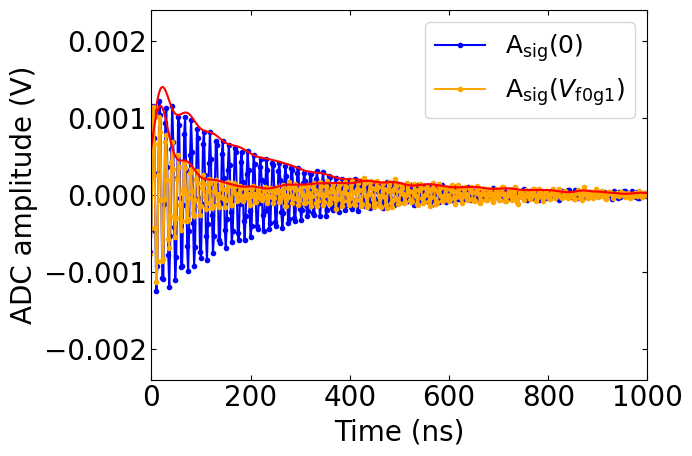

In [598]:
## absorption rate
ph_amp = 0
fogi_freq = 6
###############################################
data = ph_du7
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
freq = d[0][ph_amp]
energy = d[4][ph_amp]
ab_rate = d[5][ph_amp]
print(ab_rate)
fig = plt.figure(figsize=(8, 3))
fig, (ax0) = plt.subplots(nrows=1)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on`',left='on',right='on')
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel(r'ADC amplitude (V)')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[3][ph_amp][fogi_freq], '.-',color='blue', label=r"A${_\mathrm{sig}}$(0)")# - np.mean(y_base))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[8][ph_amp][fogi_freq], color='red')
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[2][ph_amp][fogi_freq], '.-',color='orange', label=r"A${_\mathrm{sig}(V_\mathrm{f0g1}}$)")#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq]-30,  d[7][ph_amp][fogi_freq], color='red')
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0024, 0.0024)
ax0.set_xlim(0, 1000)
plt.legend(loc = 'upper right', fontsize = 18)
# plt.tight_layout()
# plt.savefig('ph_du_utr1000_4.png', bbox_inches='tight')
# plt.show()

[95.07460566 97.80329938 98.22075721 98.79777561 98.86479789 98.81373431
 98.97632935]


d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 1000x1000 with 0 Axes>

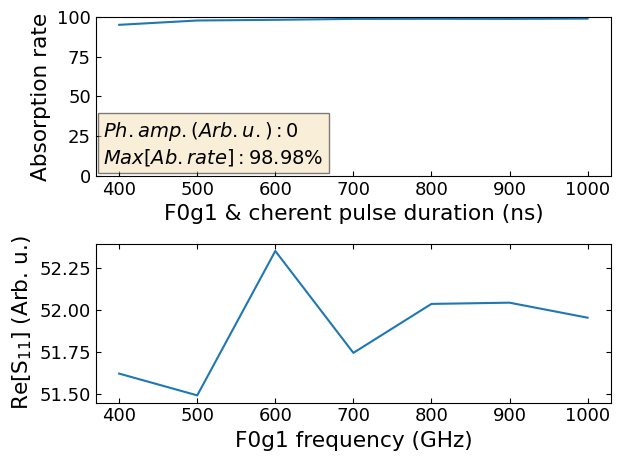

In [209]:
## absorption rate 0.1
ph_amp = 0
###############################################
data = ph_du1
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 & cherent pulse duration (ns)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp])
plt.tight_layout()
plt.show()

[91.28954744 94.82441316 97.11370512 98.37175785 98.25323846 98.09212371
 97.94444091]


<Figure size 1000x1000 with 0 Axes>

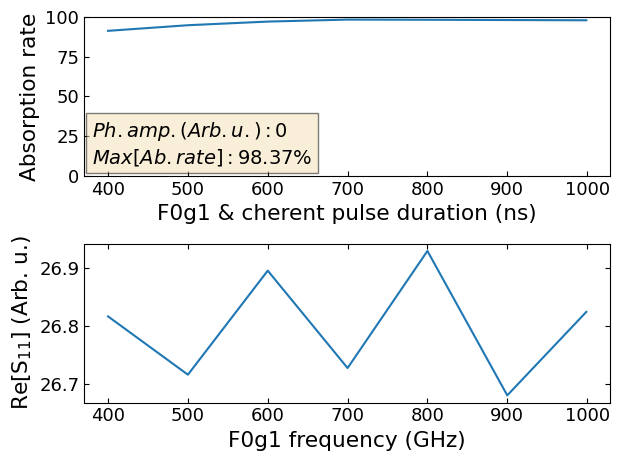

In [212]:
## absorption rate 0.2
ph_amp = 0
###############################################
data = ph_du2
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 & cherent pulse duration (ns)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(0, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp])
plt.tight_layout()
plt.show()

[88.52391323 92.43192355 94.78071665 96.06394193 96.62127253 96.96600306
 97.02308195]


<Figure size 1000x1000 with 0 Axes>

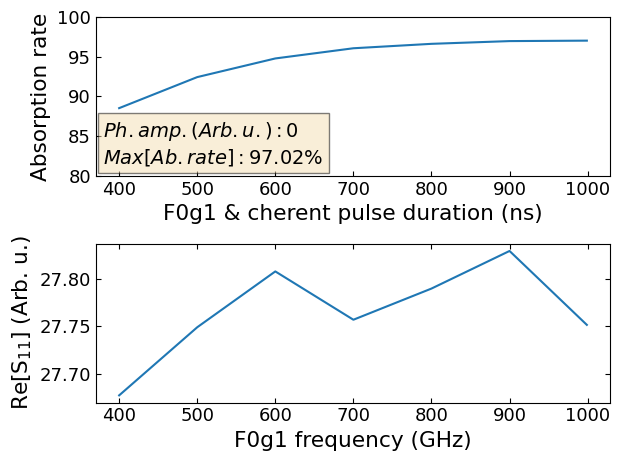

In [227]:
## absorption rate 0.4
ph_amp = 0
###############################################
data = ph_du4
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 & cherent pulse duration (ns)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(80, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp])
plt.tight_layout()
plt.show()

[80.64835633 86.34869024 88.03438489 89.94340608 91.12710809 90.96928326
 91.42913288]


<Figure size 1000x1000 with 0 Axes>

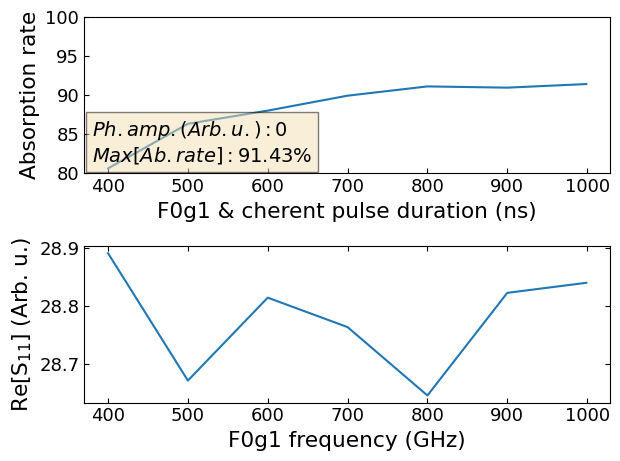

In [228]:
## absorption rate 0.7
ph_amp = 0
###############################################
data = ph_du7
num_of_ph_amp = 1
num_of_fogi_timing = 7
###############################################
d = data_acquisition_ph_du(header, data,num_of_ph_amp, num_of_fogi_timing, 78.89e6)
ab_max = np.max(d[5][ph_amp])
fig = plt.figure(figsize=(10, 10))
fig, (ax1, ax2) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on',)
textstr1 = '\n'.join((r"$Ph. amp. (Arb. u.):{}$".format(np.round(ph_amp, 2)),
                      r"$Max[Ab. rate]:{}\%$".format(np.round(ab_max, 2))))
ax1.plot(d[0][ph_amp], d[5][ph_amp])
ax1.set_xlabel('F0g1 & cherent pulse duration (ns)', size = "large")
ax1.set_ylabel('Absorption rate', size = "large")
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.35, textstr1, transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props1)
ax1.set_ylim(80, 100)

ax2.plot(d[0][ph_amp], d[6][ph_amp])
ax2.set_xlabel('F0g1 frequency (GHz)', size = "large")
ax2.set_ylabel('Re[S$_{11}$] (Arb. u.)', size = "large")
# ax2.set_ylim(-30, 15)
print( d[5][ph_amp])
plt.tight_layout()
plt.show()

mode

In [26]:
mode = "/2024-01-18/2024-01-18T181510_1426c909-76_JPA_ab_waveform_qstate_mode"

In [27]:
#data_acquisition(header, data, num_of_ph_amp, num_of_fogi_freq)[index][ph_amp][fogi_freq]
def data_acquisition_mode(header, data, num_of_ph_amp, num_of_fogi_freq, f_if):
    dd = datadict_from_hdf5(header+data+"/data")
    rates = []
    energys = []
    mode = []
    time = []
    waveform = []
    waveform_zero_fogi = []
    q_state = []
    y_absorbed_envs = []
    y_base_envs = []

    for p in range(num_of_ph_amp):
        k = p * num_of_fogi_freq
        m = dd['mode']['values'][k:k+num_of_fogi_freq]
        t = dd['time']['values'][k:k+num_of_fogi_freq]
        w = dd['waveform']['values'][k:k+num_of_fogi_freq]
        wf = dd['waveform_zero_fogi']['values'][k:k+num_of_fogi_freq]
        q = dd['qstate']['values'][k:k+num_of_fogi_freq]
        mode.append(m)
        time.append(t)
        waveform.append(w)
        waveform_zero_fogi.append(wf)
        q_state.append(q)

        rate = []
        energy = []
        y_absorbed_env = []
        y_base_env = []
        
        for n in range(len(mode[0])):
            x = time[p][n]
            y_absorbed = waveform[p][n]
            y_absorbed_shift =  y_absorbed* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_absorbed_LPF = np.array(np.abs(LPF(y_absorbed_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_absorbed_env.append(y_absorbed_LPF)
            y_base = waveform_zero_fogi[p][n]
            y_base_shift =  y_base* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
            y_base_LPF = np.array(np.abs(LPF(y_base_shift, 500e6, 20e6, 30e6, 5, 40))*2)
            y_base_env.append(y_base_LPF)
            # offset=np.mean(y_absorbed)
            # offset1=np.mean(y_base)
            E = 0
            E1 = 0
            for t in range(len(x)-40):
                t = t + 15
                E = E + (y_absorbed_LPF[t]**2)*2
                E1 = E1 + (y_base_LPF[t]**2)*2
            energy=np.append(energy, E1/100)
            rate = np.append(rate, (1 - E/E1) * 100)
        energys.append(energy)
        rates.append(rate)
        y_absorbed_envs.append(y_absorbed_env)
        y_base_envs.append(y_base_env)

        
    return mode, time, waveform, waveform_zero_fogi, energys, rates, q_state,y_absorbed_envs, y_base_envs

<Figure size 1000x1000 with 0 Axes>

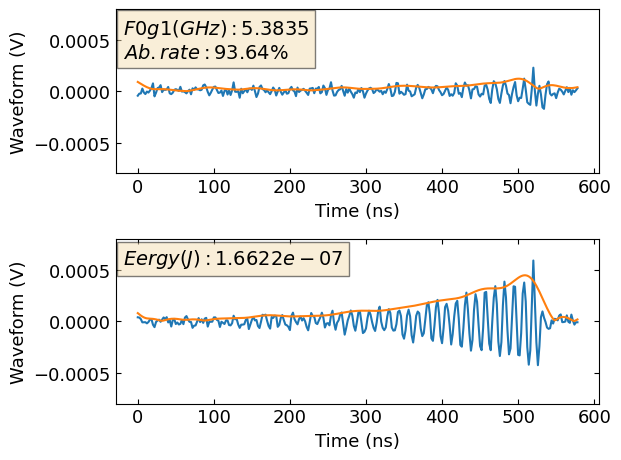

In [28]:
ph_amp = 10
fogi_freq = 0
###############################################
data = mode
num_of_ph_amp = 11
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

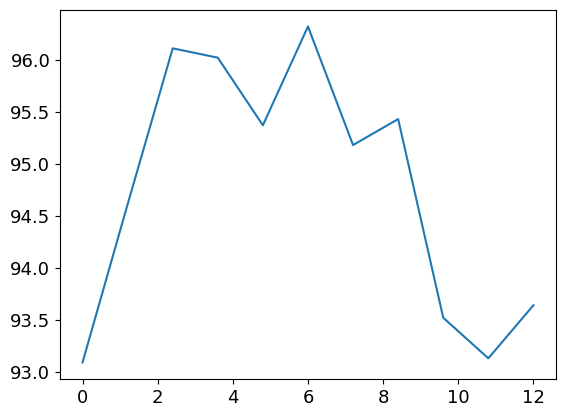

In [29]:

mode_rate = [93.09, 94.61, 96.11, 96.02, 95.37, 96.32, 95.18, 95.43, 93.52, 93.13, 93.64]
plt.plot(np.linspace(0, 12, 11), mode_rate)

In [30]:
ph_amp = 0
fogi_freq = 0
###############################################
data = mode1
num_of_ph_amp = 3
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

NameError: name 'mode1' is not defined

<Figure size 1000x1000 with 0 Axes>

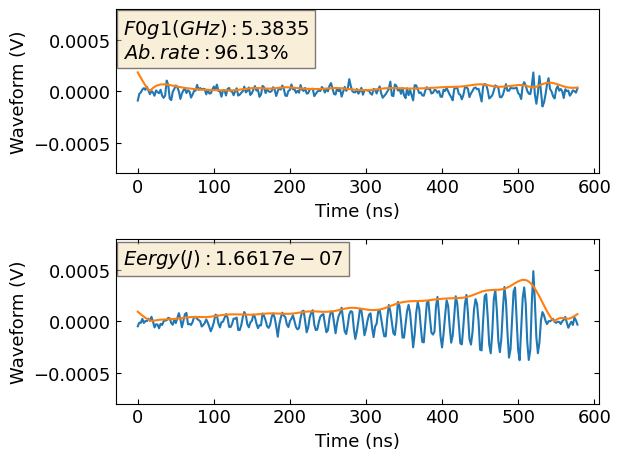

In [ ]:
ph_amp = 2
fogi_freq = 0
###############################################
data = mode2
num_of_ph_amp = 3
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

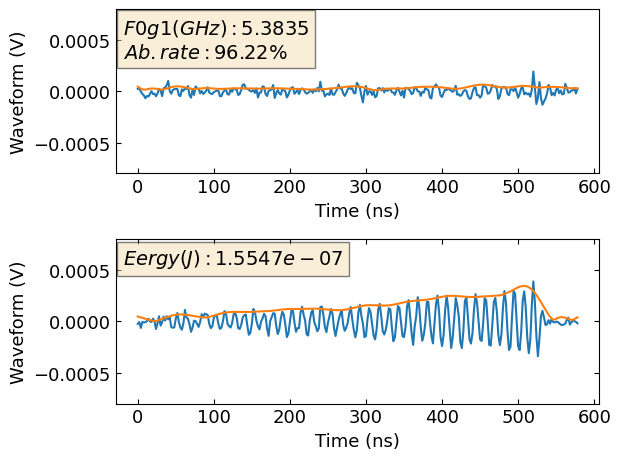

In [ ]:
ph_amp = 2
fogi_freq = 0
###############################################
data = mode3
num_of_ph_amp = 3
num_of_fogi_freq = 1
###############################################
d = data_acquisition_env_ene(header, data,num_of_ph_amp, num_of_fogi_freq, 78.89e6)
freq = d[0][ph_amp][fogi_freq]
energy = d[4][ph_amp][fogi_freq]
ab_rate = d[5][ph_amp][fogi_freq]

fig = plt.figure(figsize=(10, 10))
fig, (ax0, ax1) = plt.subplots(nrows=2)
plt.rcParams["font.size"] = 13
plt.tick_params(top='on',bottom='on`',left='on',right='on')
ax0.set_xlabel('Time (ns)')
ax0.set_ylabel('Waveform (V)')
ax0.plot(d[1][ph_amp][fogi_freq],  d[2][ph_amp][fogi_freq])#-np.mean(y_absorbed))
ax0.plot(d[1][ph_amp][fogi_freq],  d[7][ph_amp][fogi_freq])
ax0.tick_params(axis="x", direction="in")
ax0.tick_params(axis="y", direction="in")
ax0.set_ylim(-0.0008, 0.0008)
textstr0 = '\n'.join((r"$F0g1 (GHz):{}$".format(np.round(freq, 4)),
                      r"$Ab. rate:{} \%$".format(np.round(ab_rate, 2))))
props0 = dict( facecolor='wheat', alpha=0.5)
ax0.text(0.015, 0.95, textstr0, transform=ax0.transAxes,
          fontsize=14,verticalalignment='top', bbox=props0)

ax1.set_xlabel('Time (ns)')
ax1.set_ylabel('Waveform (V)')
ax1.plot(d[1][ph_amp][fogi_freq],  d[3][ph_amp][fogi_freq])# - np.mean(y_base))
ax1.plot(d[1][ph_amp][fogi_freq],  d[8][ph_amp][fogi_freq])
ax1.tick_params(axis="x", direction="in")
ax1.tick_params(axis="y", direction="in")    
ax1.set_ylim(-0.0008, 0.0008)
textstr1 = r"$Eergy (J):{}$".format(np.round(energy, 11))
props1 = dict( facecolor='wheat', alpha=0.5)
ax1.text(0.015, 0.95, textstr1, transform=ax1.transAxes,
          fontsize=14,verticalalignment='top', bbox=props1)
plt.tight_layout()
plt.show()

In [ ]:
[95.58,95.04, 96.22,  97.08, 96.62, 96.13, 95.3, 93.69, 93.85, 93.18, 91.43, 88.69, 90.18, 89.77, 85.16, 82.1, 80.48, 77.98, 82.09]